# TESLA Cavity

This notebook demonstrates a complete TESLA waveguide analysis workflow:

1. Geometry creation
2. Frequency-domain analysis
3. Model order reduction
4. Comparison with analytical solution

In [1]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
from core.em_project import EMProject

%matplotlib widget
plt.rcParams['figure.dpi'] = 100

## 1. Define Geometry

Create a rectangular waveguide with specified dimensions and mesh parameters.

In [2]:

# from geometry.importers import TESLACavity
# tesla = TESLACavity(r"tesla1cell.geo")
# tesla.save_step(r"./tesla1cell.step")

In [3]:
project_name = 'tesla1cell_direct'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)

Project 'tesla1cell_direct' exists. Loading automatically...
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct


In [4]:
# # 1. Load and prepare geometry
# geo = proj.import_geometry(r"./tesla1cell.iges", unit='mm', auto_build=False)
#
# # geo.show_split_preview()
# geo.build()
# geo.name_solids()
#
# geo.generate_mesh() # after naming solids, must generate mesh but avoid rebuilding
geo = proj.geo
geo.print_info()


STEP Geometry Information
File: C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\geometry\source_model.iges
Unit: mm
Number of solids: 1
Is split: False
Number of splitting planes: 0

Bounding Box:
  Min: (-0.1033, -0.1033, -0.2077)
  Max: (0.1033, 0.1033, 0.2077)
  Size: (0.2066, 0.2066, 0.4154)

NGSolve geometry built: True
Mesh generated: True


In [5]:
geo.show('mesh')
geo.mesh.GetBoundaries()
proj.fds.bc

WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

INFO:: 
INFO:: Structure Topology
INFO:: ============================================================
INFO:: Type: Single structure
INFO:: Domains (1): ['cell_1']
INFO:: Total Ports (2): ['port1', 'port2']
INFO:: 
Domain-Port Mapping:
  cell_1: ['port1 (external, input)', 'port2 (external, output)']


'default'

In [6]:
fom_config = {
    'nportmodes': 3,
    'order': 3,
    'nsamples': 10,
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct',
    # 'iterative_opts': {
    #     'precond': 'bddc',
    #     'maxsteps': 500,
    # },
    # 'rerun': True
}
fom_result = proj.fds.solve(config=fom_config)


Assembling Matrices...
Solving port eigenmodes...

	Calculating Port Eigenmodes...
	  Mode source: analytic
	  Polarization angle: 0.0°
	  Requested modes per port: 3
	------------------------------------------------------------
	  port1: circular (fit error: 0.0000)
	    R=0.035002
	  port2: circular (fit error: 0.0000)
	    R=0.035002
	  Precomputing boundary mass matrices (once per port)...
	    Done for 2 port(s)
here is the order of the ports ['port1', 'port2']
USING analytic for port port1
	port1 mode 0: TE_11 (cos), kc=52.6019, σ=+1
	port1 mode 1: TE_11 (sin), kc=52.6019, σ=+1
	port1 mode 2: TM_01, kc=68.7049, σ=+1


USING analytic for port port2
	port2 mode 0: TE_11 (cos), kc=52.6019, σ=-1
	port2 mode 1: TE_11 (sin), kc=52.6019, σ=-1
	port2 mode 2: TM_01, kc=68.7049, σ=-1


	------------------------------------------------------------
	Total modes: 6
boundary condition:  default
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\fd

In [7]:
proj.fds.plot_port_mode('port1', mode=0, component='abs')


Port Mode: port1 [external (input)], Mode 0
Cutoff frequency: 2.5098 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

Loaded CST S-parameters from: tesla1cell
  Frequency range: 0.0010 - 5.0000 GHz (1003 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


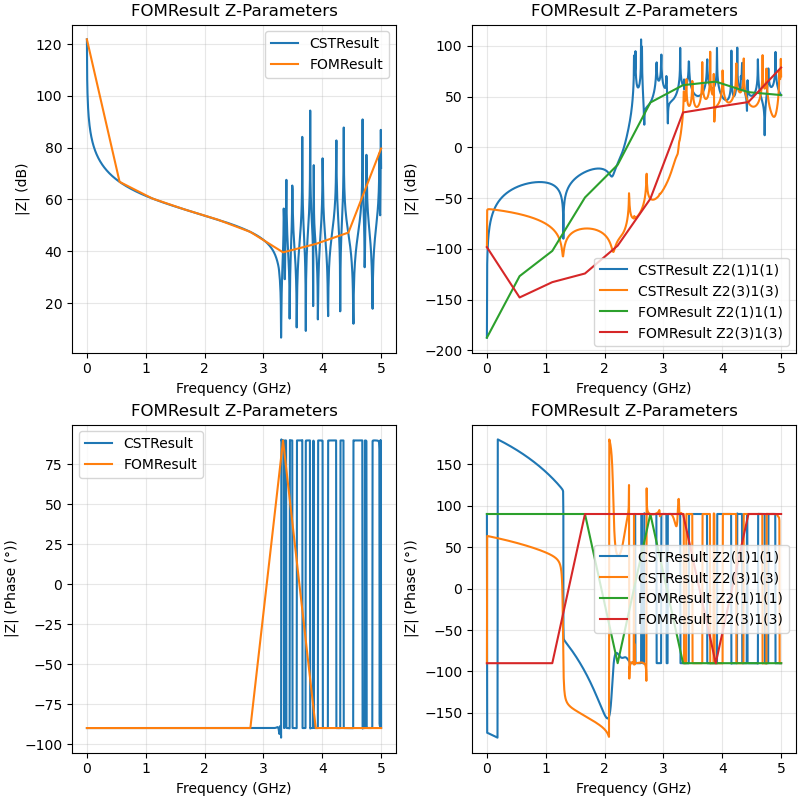

In [8]:
from analytical.cst_result import CSTResult

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell')
# plot comparison
which = [['1(3)1(3)'], ['2(1)1(1)', '2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_z(wh, ax=axs[idx+1])
    proj.fds.fom.plot_z(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_z(wh, plot_type='phase', ax=axs[idx+3])
    proj.fds.fom.plot_z(wh, plot_type='phase', ax=axs[idx+3])

In [9]:
# Reduce model order
rom = proj.fds.fom.reduce(tol=1e-15)
# concat = proj.fds.fom.rom.concatenate()
roms_config = {
    'nportmodes': 3,
    'nsamples': 1000, # <- changed for more frequency samples
    'fmin': 1e-3,
    'fmax': 5,
    'solver_type': 'direct' # <- changed to direct method, faster for smaller matrices
}
rom_result = rom.solve(config=roms_config) # solve reduced order model on more frequency samples



Model Order Reduction
INFO:: 
Domain: cell_1
Total: 245380 → 60 DOFs
Overall compression: 100.0%
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\fds
  Solve loop: 0.013s (1000 freq points)
Saving project to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct
Saved port modes to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\fds\port_modes\port_modes.pkl
INFO:: FrequencyDomainSolver saved to C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla1cell_direct\fds


Loaded CST S-parameters from: tesla1cell
  Frequency range: 0.0010 - 5.0000 GHz (1003 points)
  Ports: 2, Modes per port: 3
  S-parameters loaded: 36
  Z-parameters loaded: 36
  Y-parameters loaded: 36


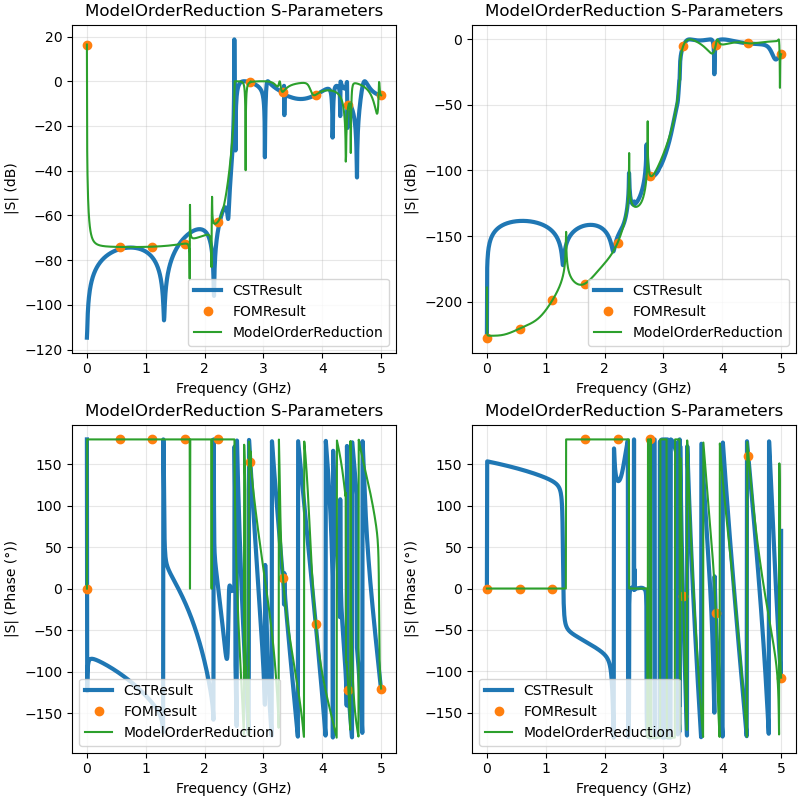

In [14]:
from analytical.cst_result import CSTResult
import matplotlib.pyplot as plt
# compare fom, rom, CST and analytical solution
# get cst solution

cstresult = CSTResult(r'C:\Users\Soske\Documents\CST\tesla1cell')
# plot comparison
which = [['1(1)1(1)'], ['2(3)1(3)']]
fig, axs = plt.subplot_mosaic([[1, 2], [3, 4]], figsize=(8, 8), layout='constrained')
for idx, wh in enumerate(which):
    # plot magnitude
    cstresult.plot_s(wh, ax=axs[idx+1], lw=3)
    proj.fds.fom.plot_s(wh, ax=axs[idx+1], marker='o', lw=0)
    rom.plot_s(wh, ax=axs[idx+1])
    # plot phase
    cstresult.plot_s(wh, plot_type='phase', ax=axs[idx+3], lw=3)
    (proj.fds.
     fom.plot_s(wh, plot_type='phase', ax=axs[idx+3], marker='o', lw=0))
    rom.plot_s(wh, plot_type='phase', ax=axs[idx+3])
plt.show()

In [11]:
proj.fds.plot_port_mode('port1', 1)


Port Mode: port1 [external (input)], Mode 1
Cutoff frequency: 2.5098 GHz


WebGuiWidget(layout=Layout(height='50vh', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.25…

  Note: global residuals are zero. This is expected when using a direct solver (solver_type='direct').


(<Figure size 600x600 with 2 Axes>,
 (<Axes: title={'center': 'global Iterative Solver Convergence (iter avg, residual min)'}, xlabel='Frequency (GHz)', ylabel='GMRES Iterations'>,
  <Axes: ylabel='Relative Residual'>))

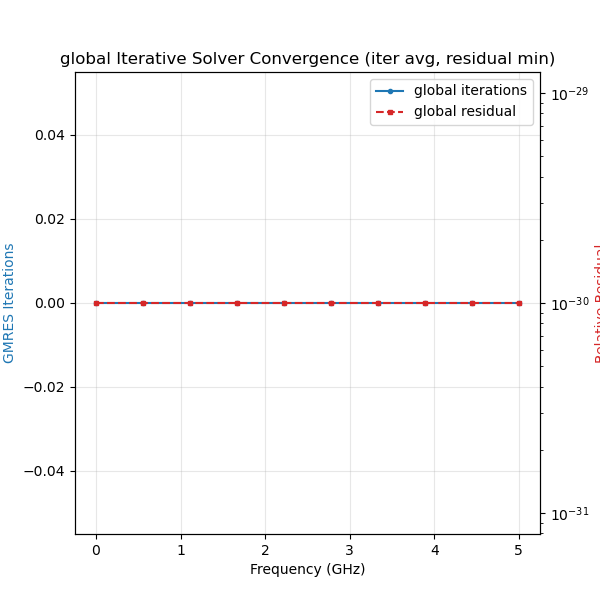

In [12]:
proj.fds.fom.plot_residual(figsize=(6, 6))

In [13]:
 proj.fds.plot_field(49)

ValueError: freq_idx 49 out of range [0, 9]

In [ ]:
proj.fds.fom.rom.calculate_resonant_modes()

In [ ]:
# fig, ax = plot_eigenfrequencies([fds, roms_concat], analytical=cstresult,
#                       labels=['FOM', 'ROM'], n_modes=50)
# ax.set_ylim(0.1, 5)
# ax.set_xlim(0.1, 5)
# plt.show()

In [ ]:
# %%time

# from netgen.occ import *
# from ngsolve import *
# from ngsolve.webgui import Draw
# from ngsolve.bem import *

# kappa=10
# order=4

# screen = WorkPlane(Axes( (0,0,0), Z, X)).RectangleC(15,15).Face()

# sp = Fuse(Sphere( (0,0,0), pi).faces)
# screen.faces.name="screen"
# sp.faces.name="sphere"
# shape = Compound([screen,sp])

# mesh = shape.GenerateMesh(maxh=5/kappa).Curve(order)
# Draw (mesh);

# fes_sphere = Compress(SurfaceL2(mesh, order=order, complex=True, definedon=mesh.Boundaries("sphere")))
# u,v = fes_sphere.TnT()
# fes_screen = Compress(SurfaceL2(mesh, order=order, dual_mapping=True, complex=True, definedon=mesh.Boundaries("screen")))
# print ("ndof_sphere = ", fes_sphere.ndof, "ndof_screen =", fes_screen.ndof)

# with TaskManager():
#     # V = HelmholtzSingleLayerPotentialOperator(fes_sphere, fes_sphere, kappa=kappa, intorder=10)
#     # K = HelmholtzDoubleLayerPotentialOperator(fes_sphere, fes_sphere, kappa=kappa, intorder=10)
#     # C = HelmholtzCombinedFieldOperator(fes_sphere, fes_sphere, kappa=kappa, intorder=10)
#     C = HelmholtzCF(u*ds("sphere"), kappa)*v*ds
#     u,v  = fes_sphere.TnT()
#     Id = BilinearForm(u*v*ds).Assemble()

# lhs = 0.5 * Id.mat + C.mat
# source = exp(1j * kappa * x)
# rhs = LinearForm(-source*v*ds).Assemble()

# gfu = GridFunction(fes_sphere)
# pre = BilinearForm(u*v*ds, diagonal=True).Assemble().mat.Inverse()
# with TaskManager():
#     gfu.vec[:] = solvers.GMRes(A=lhs, b=rhs.vec, pre=pre, maxsteps=40, tol=1e-8)

In [ ]:
# project_name = fr'C:\Users\Soske\Documents\git_projects\cavsim3d_simulations\tesla3cell'
# fds = FrequencyDomainSolver.load(project_name)

In [ ]:
# # 1. Load and prepare geometry
# midcell = STEPImporter(r"./tesla_midcell.step", auto_build=False)
# endcell_l = STEPImporter(r"./tesla_endcell_l.step", auto_build=False)
# endcell_r = STEPImporter(r"./tesla_endcell_r.step", auto_build=False)
# midcell.build()
# endcell_l.build()
# endcell_r.build()

# tesla = Assembly(main_axis='X')
# tesla.add('endcell_l', endcell_l)
# tesla.add('midcell1', midcell, after="endcell_l")
# tesla.add('endcell_r', endcell_r, after='midcell1')

# tesla.inspect()
# tesla.build()
# # geo.name_solids()
# tesla.generate_mesh(maxh=0.01)
# # tesla.mesh.GetBoundaries()

In [ ]:

from core.em_project import EMProject
import numpy as np
from ngsolve import *
from ngsolve.webgui import Draw
from netgen.occ import *
import scipy.sparse as sp

mu0 = 4 * np.pi * 1e-7
eps0 = 8.85418782e-12
c0 = 299792458

# ============================================================================
# Load STEP file and assign boundary conditions
# ============================================================================

# step_file = r"C:\Users\Soske\Documents\git_projects\cavsim3d\examples\tesla_step\tesla1cell.iges"  # <-- Change this to your STEP file path
#
# shape = OCCGeometry(step_file).shape
# # Assign boundary names using Min/Max selectors
# shape.faces.name = "pec"  # All remaining unnamed faces become PEC
# shape.faces.Min(Z).name = "port1"
# shape.faces.Max(Z).name = "port2"
# geo = OCCGeometry(shape)
# mesh = Mesh(geo.GenerateMesh())

project_name = 'tesla1cell'
base_dir = r"C:\Users\Soske\Documents\git_projects\cavsim3d_simulations"
proj = EMProject(name=project_name, base_dir=base_dir)
geo = proj.import_geometry(r"./tesla1cell.iges", unit='m', auto_build=False)
# geo.show_split_preview()
geo.build()
geo.name_solids()
geo.generate_mesh() # after naming solids, must generate mesh but avoid

print("Boundaries:", geo.mesh.GetBoundaries())
Draw(geo.mesh)

# ============================================================================
# Eigenvalue solver
# ============================================================================

order = 3
fes = HCurl(geo.mesh, order=order, dirichlet='pec')  # PMC on ports
# fes = HCurl(mesh, order=order, dirichlet='pec|port1|port2')  # PEC everywhere

u, v = fes.TnT()

a = BilinearForm(curl(u) * curl(v) * dx)
b = BilinearForm(u * v * dx)
apre = BilinearForm(curl(u) * curl(v) * dx + u * v * dx)
pre = Preconditioner(apre, type="direct", inverse="sparsecholesky")

with TaskManager():
    a.Assemble()
    b.Assemble()
    apre.Assemble()

    G, fes_h1 = fes.CreateGradient()
    GT = G.CreateTranspose()
    math1 = GT @ b.mat @ G
    math1[0, 0] += 1
    invh1 = math1.Inverse(inverse="sparsecholesky", freedofs=fes_h1.FreeDofs())

    proj = IdentityMatrix() - G @ invh1 @ GT @ b.mat
    projpre = proj @ pre.mat

    evals, evecs = solvers.PINVIT(a.mat, b.mat, pre=projpre, num=10, maxit=20, printrates=False)

# Results
for i, lam in enumerate(evals):
    freq = c0 * np.sqrt(np.abs(lam)) / (2 * np.pi) / 1e9
    print(f"Mode {i}: {freq:.4f} GHz")

gfu = GridFunction(fes)
gfu.vec.data = evecs[0]
Draw(Norm(gfu), geo.mesh)